# 1. Problem statement :
 Developed an end-to-end Customer Intelligence System using classification, ensemble learning (Random Forest, XGBoost), and clustering (K-Means, DBSCAN), achieving optimized predictive performance and actionable customer segmentation insights.

 Data set :
 https://www.kaggle.com/datasets/rohan0301/unsupervised-learning-on-country-data

# 2. Importing libraries :

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings("ignore")

# 3. Reading Data set:

In [2]:
df = pd.read_csv("Countrydata.csv")

In [3]:
display(df.head())
display(df.shape)
display(df.columns)
display(df.info())

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


(167, 10)

Index(['country', 'child_mort', 'exports', 'health', 'imports', 'income',
       'inflation', 'life_expec', 'total_fer', 'gdpp'],
      dtype='object')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


None

In [4]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


In [5]:
df.duplicated().sum()

np.int64(0)

#4. Data cleaning and Preprocessing:

In [6]:
df.columns = df.columns.str.strip()

df.drop_duplicates(inplace=True)

for col in df.columns:
    if col != 'country':
        df[col] = pd.to_numeric(df[col], errors='coerce')

for col in df.columns:
    if col != 'country':
        df[col].fillna(df[col].median(), inplace=True)

display(df.head())
print("Shape:", df.shape)
print("\nMissing Values:")
display(df.isnull().sum())

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


Shape: (167, 10)

Missing Values:


,0
country,0
child_mort,0
exports,0
health,0
imports,0
income,0
inflation,0
life_expec,0
total_fer,0
gdpp,0


After performing the cleaning process, the dataset was found to be already well-structured:

- Total Records: **167**
- Total Features: **10**
- Duplicate Records: **0**
- Missing Values: **0**

#5. Separate Country Names and Scale Features:

### Feature Selection and Scaling

The `country` column acts as an identifier and does not contribute to numerical clustering. Therefore, it is separated from the dataset, and only the continuous numerical features are retained for analysis.

Since clustering algorithms such as K-Means and DBSCAN are distance-based methods, feature scaling is essential to ensure that variables with larger magnitudes (e.g., income and GDP) do not dominate variables with smaller magnitudes (e.g., health expenditure and inflation).

To standardize the feature space, the StandardScaler technique is applied, transforming each feature to have a mean of 0 and a standard deviation of 1.

In [7]:
countries = df['country']

X = df.drop('country', axis=1)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Original Shape:", X.shape)
print("Scaled Shape:", X_scaled.shape)

Original Shape: (167, 9)
Scaled Shape: (167, 9)


#6. Elbow Method:

### Determining the Optimal Number of Clusters

Before applying K-Means clustering, it is important to determine an appropriate number of clusters (K).

The Elbow Method is used to evaluate clustering performance across different values of K. For each cluster count, the inertia (Within-Cluster Sum of Squares) is calculated.

The optimal value of K is typically identified at the "elbow point," where adding additional clusters results in diminishing improvements in inertia.

In [8]:
# Calculate Inertia
inertia = []

k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

print(inertia)

[1050.2145582853307, 831.424435208687, 700.52053697222, 620.163371288842, 558.4696598590399, 495.8079455215346, 457.5861478912421, 427.80367198134667, 403.2296125136434]


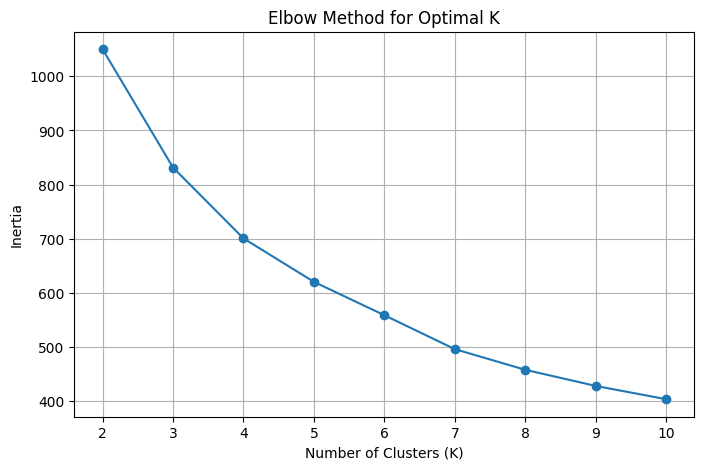

In [9]:
# Plot the Elbow Curve
plt.figure(figsize=(8,5))

plt.plot(k_range, inertia, marker='o')

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')

plt.title('Elbow Method for Optimal K')

plt.grid(True)

plt.show()

### Elbow Method Observation

The elbow curve shows a substantial reduction in inertia when increasing the number of clusters from 2 to 3. Beyond K = 3, the rate of decrease becomes more gradual, indicating diminishing returns from adding additional clusters.

Therefore, **K = 3** is selected as the optimal number of clusters for K-Means clustering, providing a good balance between cluster compactness and model simplicity.

#7. K-Means clustering:

### K-Means Clustering

Using the optimal cluster count identified through the Elbow Method (K = 3), a K-Means clustering model is trained on the standardized dataset.

The model assigns each country to one of three clusters based on similarities in socioeconomic and development indicators.

In [10]:
# Train K-Means with optimal K
best_k = 3

kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_scaled)

# Add cluster labels to dataset
df['KMeans_Cluster'] = kmeans_labels

display(df.head())

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,KMeans_Cluster
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,1
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,2
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,2
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,1
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,2


#8. Evaluate Clustering Using Silhouette Score:

### Clustering Evaluation using Silhouette Score

To evaluate the quality of the K-Means clustering model, the Silhouette Score is calculated.

The Silhouette Score measures how similar a data point is to its own cluster compared to other clusters.

- A score close to **+1** indicates well-separated clusters.
- A score near **0** indicates overlapping clusters.
- A score below **0** suggests incorrect cluster assignments.

Higher silhouette scores indicate better clustering performance.

In [11]:
# Calculate Silhouette Score

sil_score = silhouette_score(
    X_scaled,
    kmeans_labels
)

print(f"Silhouette Score: {sil_score:.4f}")

Silhouette Score: 0.2833


#9. DBSCAN Clustering:

### DBSCAN Clustering

To compare the performance of K-Means, a Density-Based Spatial Clustering of Applications with Noise (DBSCAN) model is applied.

Unlike K-Means, DBSCAN does not require a predefined number of clusters and can identify outliers as noise points. It groups together observations that are closely packed while marking isolated observations as noise.

The model is configured with:

- eps = 1.5
- min_samples = 5

In [12]:
# Train DBSCAN

dbscan = DBSCAN(
    eps=1.5,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(X_scaled)

df['DBSCAN_Cluster'] = dbscan_labels

display(df['DBSCAN_Cluster'].value_counts())

,count
DBSCAN_Cluster,
0,137
-1,30


### DBSCAN Clustering Observation

The DBSCAN model identified one major cluster containing 137 countries and classified 30 countries as noise (outliers).




#10. PCA Visualization

### Principal Component Analysis (PCA) Visualization

The dataset contains nine numerical features, making direct visualization difficult.

Principal Component Analysis (PCA) is applied to reduce the dimensionality of the data from nine features to two principal components while preserving as much variance as possible.

The resulting two-dimensional representation allows visualization of the country clusters identified by the K-Means algorithm.

In [13]:
# Apply PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("Original Dimensions:", X_scaled.shape)
print("Reduced Dimensions:", X_pca.shape)

Original Dimensions: (167, 9)
Reduced Dimensions: (167, 2)


In [14]:
# Create PCA DataFrame

pca_df = pd.DataFrame(
    X_pca,
    columns=['PC1', 'PC2']
)

# Add K-Means cluster labels
pca_df['Cluster'] = kmeans_labels

pca_df.head()

,PC1,PC2,Cluster
0,-2.913025,0.095621,1
1,0.429911,-0.588156,2
2,-0.285225,-0.455174,2
3,-2.932423,1.695555,1
4,1.033576,0.136659,2


#11. PCA Scatter Plot:

### PCA-Based Cluster Visualization

To better understand the cluster structure, the countries are projected onto two principal components obtained through PCA.

Each point represents a country, and colors indicate the cluster assigned by the K-Means algorithm. This visualization helps identify separation patterns and similarities among countries based on their socioeconomic indicators.

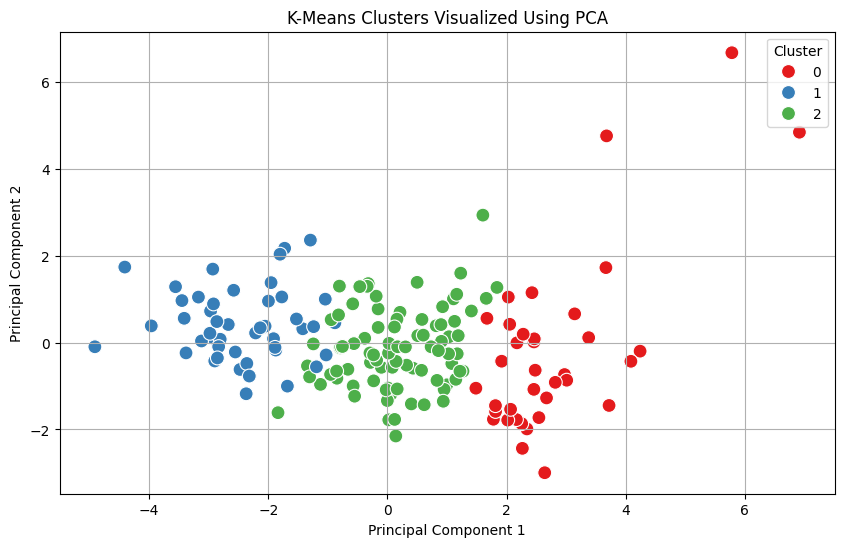

In [15]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='Set1',
    s=100
)

plt.title('K-Means Clusters Visualized Using PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

plt.legend(title='Cluster')

plt.grid(True)

plt.show()

### PCA Visualization Observation

The PCA projection shows that the K-Means algorithm successfully grouped countries into three distinct clusters. While some overlap exists between neighboring clusters, a noticeable separation can be observed along the principal components.

The visualization indicates that countries with similar socioeconomic characteristics tend to be grouped together, supporting the effectiveness of the clustering approach. The moderate overlap observed is consistent with the silhouette score obtained earlier, reflecting the complex nature of real-world development indicators.

# 12. Cluster Analysis:

In [16]:
cluster_summary = df.groupby(
    'KMeans_Cluster'
).mean(numeric_only=True)

display(cluster_summary)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,DBSCAN_Cluster
KMeans_Cluster,,,,,,,,,,
0,5.000000,58.738889,8.807778,51.491667,45672.222222,2.671250,80.127778,1.752778,42494.444444,-0.250000
1,92.961702,29.151277,6.388511,42.323404,3942.404255,12.019681,59.187234,5.008085,1922.382979,-0.340426
2,21.927381,40.243917,6.200952,47.473404,12305.595238,7.600905,72.814286,2.307500,6486.452381,-0.059524


#13. Cluster Analysis and Key Observations

### Observation 1: Highly Developed Economies (Cluster 0)

- Cluster 0 represents the most developed countries in the dataset. These countries exhibit the highest average income ($45,672), highest GDP per capita ($42,494), and longest life expectancy (80.1 years). Additionally, they have the lowest child mortality rate (5.0), indicating strong healthcare systems and overall economic prosperity.

### Observation 2: Low Development and High Mortality Countries (Cluster 1)

- Cluster 1 consists of the least developed countries. This group has the lowest average income ($3,942) and GDP per capita ($1,922), combined with the highest child mortality rate (92.96) and lowest life expectancy (59.19 years). These countries may require the greatest developmental support and policy intervention.

### Observation 3: Developing Economies (Cluster 2)

- Cluster 2 represents developing countries positioned between the other two groups. These countries demonstrate moderate income levels ($12,306), moderate GDP per capita ($6,486), and a life expectancy of approximately 72.8 years. Their socioeconomic indicators suggest ongoing economic growth and development.

### Observation 4: Relationship Between Income and Health Outcomes

- A strong relationship can be observed between economic indicators and health outcomes. Countries with higher income and GDP generally show lower child mortality rates and higher life expectancy, highlighting the impact of economic development on quality of life.

### Observation 5: Effectiveness of Clustering

- The clustering process successfully segmented countries into meaningful groups based on socioeconomic characteristics. The resulting clusters provide actionable insights for identifying highly developed nations, developing economies, and countries facing significant developmental challenges.

#14. Displaying Cluster Summary:

In [17]:
display(cluster_summary)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,DBSCAN_Cluster
KMeans_Cluster,,,,,,,,,,
0,5.000000,58.738889,8.807778,51.491667,45672.222222,2.671250,80.127778,1.752778,42494.444444,-0.250000
1,92.961702,29.151277,6.388511,42.323404,3942.404255,12.019681,59.187234,5.008085,1922.382979,-0.340426
2,21.927381,40.243917,6.200952,47.473404,12305.595238,7.600905,72.814286,2.307500,6486.452381,-0.059524


#15. Final Conclusion:



This project applied data preprocessing, feature scaling, K-Means clustering, DBSCAN clustering, and PCA-based visualization to analyze socioeconomic indicators across 167 countries.

The Elbow Method identified **K = 3** as the optimal number of clusters. The K-Means model achieved a silhouette score of **0.2833**, indicating moderate but meaningful cluster separation. PCA visualization further demonstrated the presence of distinct country groupings.

The analysis revealed three major segments:

- Highly developed countries with high income, high GDP, and low child mortality.
- Developing countries with moderate economic and social indicators.
- Low-development countries characterized by low income, low GDP, high fertility rates, and high child mortality.

Overall, the clustering approach successfully transformed complex multidimensional socioeconomic data into interpretable country segments, providing valuable insights into global development patterns.